In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
import os

pd.set_option('display.width', 170)
OUT_DIR = 'outputs'; FIG_DIR = 'outputs/figures'; os.makedirs(FIG_DIR, exist_ok=True)
rng = np.random.default_rng(0)

d = pd.read_parquet(f'{OUT_DIR}/analytic_with_weights.parquet')
T = d['T'].values
w0 = d['overlap_weight'].values
CONF = ['age', 'mariee', 'revenu_ord', 'instruction_ord', 'agri_elevage',
        'nb_grossesses', 'nb_enfants', 'antecedent_complication',
        'accouchement_dystocique', 'wealth_index']
print('Chargé :', d.shape)

Chargé : (654, 26)


In [2]:
def fit_weights(data):
    X = pd.concat([data[CONF], pd.get_dummies(data['site'], prefix='s', drop_first=True)], axis=1).astype(float)
    Xz = StandardScaler().fit_transform(X)
    e = LogisticRegression(C=1.0, max_iter=5000).fit(Xz, data['T'].values).predict_proba(Xz)[:, 1]
    Tt = data['T'].values
    return np.where(Tt == 1, 1 - e, e)

def wmean_diff(y, Tt, w):
    m = ~np.isnan(y)
    yt, wt = y[m & (Tt == 1)], w[m & (Tt == 1)]
    yc, wc = y[m & (Tt == 0)], w[m & (Tt == 0)]
    return np.average(yt, weights=wt) - np.average(yc, weights=wc)

def raw_diff(y, Tt):
    m = ~np.isnan(y)
    return y[m & (Tt == 1)].mean() - y[m & (Tt == 0)].mean()

def adj_effect(y, Tt, w, Xmat):
    m = ~np.isnan(y)
    A = np.column_stack([Tt[m], Xmat[m]])
    return LinearRegression().fit(A, y[m], sample_weight=w[m]).coef_[0]

In [3]:
OUTCOMES = {'oop_total': 'Dépense directe (FCFA)',
            'exces_k05': 'Dépense excessive (k=0,5)',
            'exces_k10': 'Dépense excessive (k=1,0)',
            'exces_k15': 'Dépense excessive (k=1,5)',
            'cascade_score': 'Score de cascade (0-4)',
            'cascade_complete': 'Continuum complet (risque)'}
Xmat = StandardScaler().fit_transform(d[CONF].astype(float).values)
idx_t, idx_c = np.where(T == 1)[0], np.where(T == 0)[0]
B = 1000

rows = []
for v, lab in OUTCOMES.items():
    y = pd.to_numeric(d[v], errors='coerce').astype(float).values
    ato = wmean_diff(y, T, w0)
    adj = adj_effect(y, T, w0, Xmat)
    raw = raw_diff(y, T)
    boot = []
    for _ in range(B):
        bi = np.concatenate([rng.choice(idx_t, len(idx_t), replace=True),
                             rng.choice(idx_c, len(idx_c), replace=True)])
        db = d.iloc[bi].reset_index(drop=True)
        wb = fit_weights(db)
        yb = pd.to_numeric(db[v], errors='coerce').astype(float).values
        boot.append(wmean_diff(yb, db['T'].values, wb))
    lo, hi = np.nanpercentile(boot, [2.5, 97.5])
    sig = '✓' if (lo > 0) == (hi > 0) else '—'
    rows.append((lab, round(raw, 3), round(ato, 3), round(lo, 3), round(hi, 3), round(adj, 3), sig))

R = pd.DataFrame(rows, columns=['résultat', 'effet_brut', 'ATO', 'IC95_bas', 'IC95_haut', 'ATO_ajusté', 'signif'])
print(R.to_string(index=False))

                  résultat  effet_brut        ATO   IC95_bas  IC95_haut  ATO_ajusté signif
    Dépense directe (FCFA)  -27713.608 -28259.772 -37377.304 -19427.239  -28252.193      ✓
 Dépense excessive (k=0,5)      -0.074     -0.074     -0.123     -0.024      -0.074      ✓
 Dépense excessive (k=1,0)      -0.031     -0.055     -0.098     -0.018      -0.055      ✓
 Dépense excessive (k=1,5)      -0.009     -0.035     -0.076     -0.003      -0.035      ✓
    Score de cascade (0-4)       0.056      0.305      0.162      0.452       0.305      ✓
Continuum complet (risque)       0.006      0.184      0.092      0.274       0.184      ✓


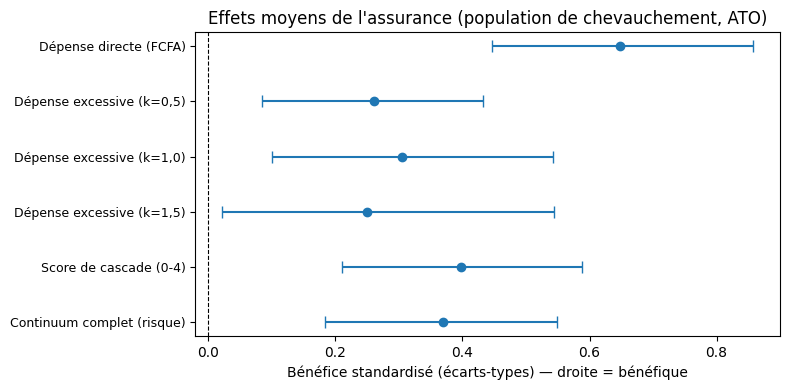

In [4]:
sd = {v: pd.to_numeric(d[v], errors='coerce').std() for v in OUTCOMES}
sign = {'oop_total': -1, 'exces_k05': -1, 'exces_k10': -1, 'exces_k15': -1,
        'cascade_score': +1, 'cascade_complete': +1}  
fig, ax = plt.subplots(figsize=(8, 4))
for i, (v, lab) in enumerate(OUTCOMES.items()):
    r = R.iloc[i]
    b = sign[v] * r['ATO'] / sd[v]
    l, h = sorted([sign[v] * r['IC95_bas'] / sd[v], sign[v] * r['IC95_haut'] / sd[v]])
    ax.errorbar(b, i, xerr=[[b - l], [h - b]], fmt='o', color='#1f77b4', capsize=4)
ax.axvline(0, color='k', ls='--', lw=0.8)
ax.set_yticks(range(len(OUTCOMES))); ax.set_yticklabels(list(OUTCOMES.values()), fontsize=9)
ax.set_xlabel('Bénéfice standardisé (écarts-types) — droite = bénéfique')
ax.set_title('Effets moyens de l\'assurance (population de chevauchement, ATO)')
ax.invert_yaxis(); fig.tight_layout()
fig.savefig(f'{FIG_DIR}/effets_moyens.png', dpi=150)
plt.show()

In [5]:
R.to_csv(f'{OUT_DIR}/effets_moyens.csv', index=False, encoding='utf-8-sig')
print('Sauvegardé : effets_moyens.csv, figure effets_moyens.png')

Sauvegardé : effets_moyens.csv, figure effets_moyens.png
